# Sudoku via Convex Relaxation

**Solving combinatorial puzzles with LP relaxation using Moreau** — a fun closer showing that integer programs can sometimes be solved exactly via their linear relaxation.

This notebook demonstrates:
- Encoding Sudoku as a linear program with 729 binary variables
- Solving the LP relaxation with `moreau.Solver` (and recovering the integer solution)
- Exploring the LP relaxation phase transition — when convex relaxation recovers exact integer solutions
- **Batched solving**: 256 puzzles simultaneously with `CompiledSolver` on GPU

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import moreau
from utils.style import set_moreau_style, MOREAU_COLORS, moreau_gradient
from utils.sparse import sparse_to_csr

set_moreau_style()
np.random.seed(42)

## Sudoku as a Linear Program

A standard 9x9 Sudoku puzzle can be encoded as a binary integer program. The key insight is that the LP relaxation (replacing $x \in \{0,1\}$ with $0 \le x \le 1$) often yields an integer solution for well-posed puzzles.

**Variables:** 729 binary variables $x_{i,j,k}$ where $x_{i,j,k} = 1$ means digit $k+1$ occupies cell $(i, j)$.

**Constraints (all equalities, 324 total):**
- **Cell:** Each cell has exactly one digit: $\sum_k x_{i,j,k} = 1$ for all $i,j$ (81 constraints)
- **Row:** Each row has each digit once: $\sum_j x_{i,j,k} = 1$ for all $i,k$ (81 constraints)
- **Column:** Each column has each digit once: $\sum_i x_{i,j,k} = 1$ for all $j,k$ (81 constraints)
- **Box:** Each 3x3 box has each digit once: $\sum_{(i,j) \in \text{box}} x_{i,j,k} = 1$ for all box, $k$ (81 constraints)

**Clue constraints:** For each given digit, $x_{i,j,k} = \text{clue value}$ (additional equalities).

**Box bounds:** $0 \le x_{i,j,k} \le 1$ (729 lower + 729 upper = 1458 nonneg constraints).

**LP formulation** in Moreau's standard form $\min \frac{1}{2} x^\top P x + q^\top x$ s.t. $Ax + s = b$, $s \in \mathcal{K}$:
- $P = 0$ (this is an LP, no quadratic term)
- $q$ = small random perturbation (to break LP degeneracy)
- $A$ stacks: structural equalities, clue equalities, lower bounds ($-I$), upper bounds ($I$)
- $b$ = ones for structural constraints, clue values, zeros for lower bounds, ones for upper bounds
- Cones: `num_zero_cones` = 324 + n_clues, `num_nonneg_cones` = 2 * 729

In [2]:
# CVXPY equivalent:
#   import cvxpy as cp
#   X = cp.Variable((9, 9, 9))
#   constraints = [X >= 0, X <= 1]
#   constraints += [cp.sum(X, axis=2) == 1]  # one digit per cell
#   constraints += [cp.sum(X, axis=0) == 1]  # each digit once per column
#   constraints += [cp.sum(X, axis=1) == 1]  # each digit once per row
#   for br in range(3):
#       for bc in range(3):
#           for k in range(9):
#               constraints += [cp.sum(X[3*br:3*br+3, 3*bc:3*bc+3, k]) == 1]
#   for (i, j, d) in clues:
#       constraints += [X[i, j, d-1] == 1]
#   prob = cp.Problem(cp.Minimize(cp.sum(cp.multiply(q, X))), constraints)
#   prob.solve()

def var_index(i, j, k):
    """Map cell (i,j) and digit k (0-indexed) to variable index in [0, 729)."""
    return i * 81 + j * 9 + k


def build_sudoku_lp(puzzle):
    """Build the LP matrices for a Sudoku puzzle.

    Parameters
    ----------
    puzzle : list of list of int
        9x9 grid where 0 means empty, 1-9 are clues.

    Returns
    -------
    P : sparse (729, 729) — zero matrix (LP)
    q : ndarray (729,) — small random perturbation
    A : sparse (m, 729) — constraint matrix
    b : ndarray (m,) — constraint RHS
    cones : moreau.Cones
    clue_cells : list of (i, j, digit) — the given clues
    """
    n_vars = 729  # 9 * 9 * 9

    # --- Identify clues ---
    clue_cells = []
    for i in range(9):
        for j in range(9):
            if puzzle[i][j] != 0:
                clue_cells.append((i, j, puzzle[i][j]))
    n_clues = len(clue_cells)

    # --- P: zero matrix (LP) ---
    P = sparse.csr_array((n_vars, n_vars), dtype=np.float64)

    # --- q: small random perturbation to break LP degeneracy ---
    rng = np.random.default_rng(0)
    q = rng.uniform(1e-6, 1e-5, size=n_vars).astype(np.float64)

    # --- Build equality constraint rows ---
    eq_rows = []  # list of (row_idx, col_idx, val) triples
    eq_b = []     # RHS values
    row_counter = 0

    # 1. Cell constraints: sum_k x[i,j,k] = 1 for all i,j (81 constraints)
    for i in range(9):
        for j in range(9):
            for k in range(9):
                eq_rows.append((row_counter, var_index(i, j, k), 1.0))
            eq_b.append(1.0)
            row_counter += 1

    # 2. Row constraints: sum_j x[i,j,k] = 1 for all i,k (81 constraints)
    for i in range(9):
        for k in range(9):
            for j in range(9):
                eq_rows.append((row_counter, var_index(i, j, k), 1.0))
            eq_b.append(1.0)
            row_counter += 1

    # 3. Column constraints: sum_i x[i,j,k] = 1 for all j,k (81 constraints)
    for j in range(9):
        for k in range(9):
            for i in range(9):
                eq_rows.append((row_counter, var_index(i, j, k), 1.0))
            eq_b.append(1.0)
            row_counter += 1

    # 4. Box constraints: sum_{(i,j) in box} x[i,j,k] = 1 for all box,k (81 constraints)
    for box_r in range(3):
        for box_c in range(3):
            for k in range(9):
                for di in range(3):
                    for dj in range(3):
                        i = box_r * 3 + di
                        j = box_c * 3 + dj
                        eq_rows.append((row_counter, var_index(i, j, k), 1.0))
                eq_b.append(1.0)
                row_counter += 1

    n_structural_eq = row_counter  # should be 324

    # 5. Clue constraints: x[i,j,k-1] = 1 for each clue (i,j,digit)
    for (ci, cj, digit) in clue_cells:
        eq_rows.append((row_counter, var_index(ci, cj, digit - 1), 1.0))
        eq_b.append(1.0)
        row_counter += 1

    n_eq = row_counter  # 324 + n_clues

    # Build equality block as sparse matrix
    eq_row_idx = [r for (r, c, v) in eq_rows]
    eq_col_idx = [c for (r, c, v) in eq_rows]
    eq_vals = [v for (r, c, v) in eq_rows]
    A_eq = sparse.csr_array(
        (np.array(eq_vals, dtype=np.float64),
         (np.array(eq_row_idx), np.array(eq_col_idx))),
        shape=(n_eq, n_vars)
    )
    b_eq = np.array(eq_b, dtype=np.float64)

    # --- Box bounds: 0 <= x <= 1 ---
    # Lower bound: -x + s = 0, s >= 0  =>  x >= 0
    A_lower = -sparse.eye(n_vars, dtype=np.float64, format='csr')
    b_lower = np.zeros(n_vars, dtype=np.float64)

    # Upper bound: x + s = 1, s >= 0  =>  x <= 1
    A_upper = sparse.eye(n_vars, dtype=np.float64, format='csr')
    b_upper = np.ones(n_vars, dtype=np.float64)

    # --- Stack: zero cones (equalities) first, then nonneg cones (bounds) ---
    A = sparse.vstack([A_eq, A_lower, A_upper], format='csr')
    A.sort_indices()
    b = np.concatenate([b_eq, b_lower, b_upper])

    n_nonneg = 2 * n_vars  # 1458
    cones = moreau.Cones(num_zero_cones=n_eq, num_nonneg_cones=n_nonneg)

    print(f"Variables:          {n_vars}")
    print(f"Structural eq:      {n_structural_eq}")
    print(f"Clue eq:            {n_clues}")
    print(f"Total equalities:   {n_eq}")
    print(f"Nonneg (bounds):    {n_nonneg}")
    print(f"Total constraints:  {A.shape[0]}")
    print(f"A shape:            {A.shape}, nnz = {A.nnz}")

    return P, q, A, b, cones, clue_cells

In [3]:
# A moderately difficult Sudoku puzzle (0 = empty)
puzzle = [
    [5, 3, 0,  0, 7, 0,  0, 0, 0],
    [6, 0, 0,  1, 9, 5,  0, 0, 0],
    [0, 9, 8,  0, 0, 0,  0, 6, 0],
    [8, 0, 0,  0, 6, 0,  0, 0, 3],
    [4, 0, 0,  8, 0, 3,  0, 0, 1],
    [7, 0, 0,  0, 2, 0,  0, 0, 6],
    [0, 6, 0,  0, 0, 0,  2, 8, 0],
    [0, 0, 0,  4, 1, 9,  0, 0, 5],
    [0, 0, 0,  0, 8, 0,  0, 7, 9],
]

# Count clues
n_given = sum(1 for row in puzzle for v in row if v != 0)
print(f"Puzzle has {n_given} given clues, {81 - n_given} cells to fill")

Puzzle has 30 given clues, 51 cells to fill


In [4]:
# Build LP and solve
P, q, A, b, cones, clue_cells = build_sudoku_lp(puzzle)

solver = moreau.Solver(P, q, A, b, cones=cones)
sol = solver.solve()

print(f"\nStatus:     {solver.info.status.name}")
print(f"Objective:  {solver.info.obj_val:.6f}")
print(f"Iterations: {solver.info.iterations}")

Variables:          729
Structural eq:      324
Clue eq:            30
Total equalities:   354
Nonneg (bounds):    1458
Total constraints:  1812
A shape:            (1812, 729), nnz = 4404

Status:     Solved
Objective:  0.000478
Iterations: 9


In [5]:
# Extract and verify the solution
x_raw = sol.x.reshape(9, 9, 9)

# Round to integers: for each cell, pick the digit with highest value
board = np.argmax(x_raw, axis=2) + 1  # digits 1-9

print("Solved board:")
for i in range(9):
    if i % 3 == 0 and i > 0:
        print("------+-------+------")
    row_str = ""
    for j in range(9):
        if j % 3 == 0 and j > 0:
            row_str += "| "
        row_str += f"{board[i, j]} "
    print(row_str)

# Verify correctness
def verify_sudoku(board):
    """Check that the board is a valid completed Sudoku."""
    target = set(range(1, 10))
    # Check rows
    for i in range(9):
        if set(board[i]) != target:
            return False, f"Row {i} invalid: {sorted(board[i])}"
    # Check columns
    for j in range(9):
        if set(board[:, j]) != target:
            return False, f"Col {j} invalid: {sorted(board[:, j])}"
    # Check 3x3 boxes
    for br in range(3):
        for bc in range(3):
            box = board[br*3:(br+1)*3, bc*3:(bc+1)*3].ravel()
            if set(box) != target:
                return False, f"Box ({br},{bc}) invalid: {sorted(box)}"
    return True, "Valid Sudoku!"

valid, msg = verify_sudoku(board)
print(f"\nVerification: {msg}")

# Check integrality of the relaxed solution
integrality_gap = np.min(np.abs(x_raw * (1 - x_raw)))  # should be ~0 if integer
max_fractional = np.max(np.minimum(x_raw, 1 - x_raw))
print(f"Max fractional deviation from 0/1: {max_fractional:.2e}")

Solved board:
5 3 4 | 6 7 8 | 9 1 2 
6 7 2 | 1 9 5 | 3 4 8 
1 9 8 | 3 4 2 | 5 6 7 
------+-------+------
8 5 9 | 7 6 1 | 4 2 3 
4 2 6 | 8 5 3 | 7 9 1 
7 1 3 | 9 2 4 | 8 5 6 
------+-------+------
9 6 1 | 5 3 7 | 2 8 4 
2 8 7 | 4 1 9 | 6 3 5 
3 4 5 | 2 8 6 | 1 7 9 

Verification: Valid Sudoku!
Max fractional deviation from 0/1: 3.86e-10


## Visualizing the Solution

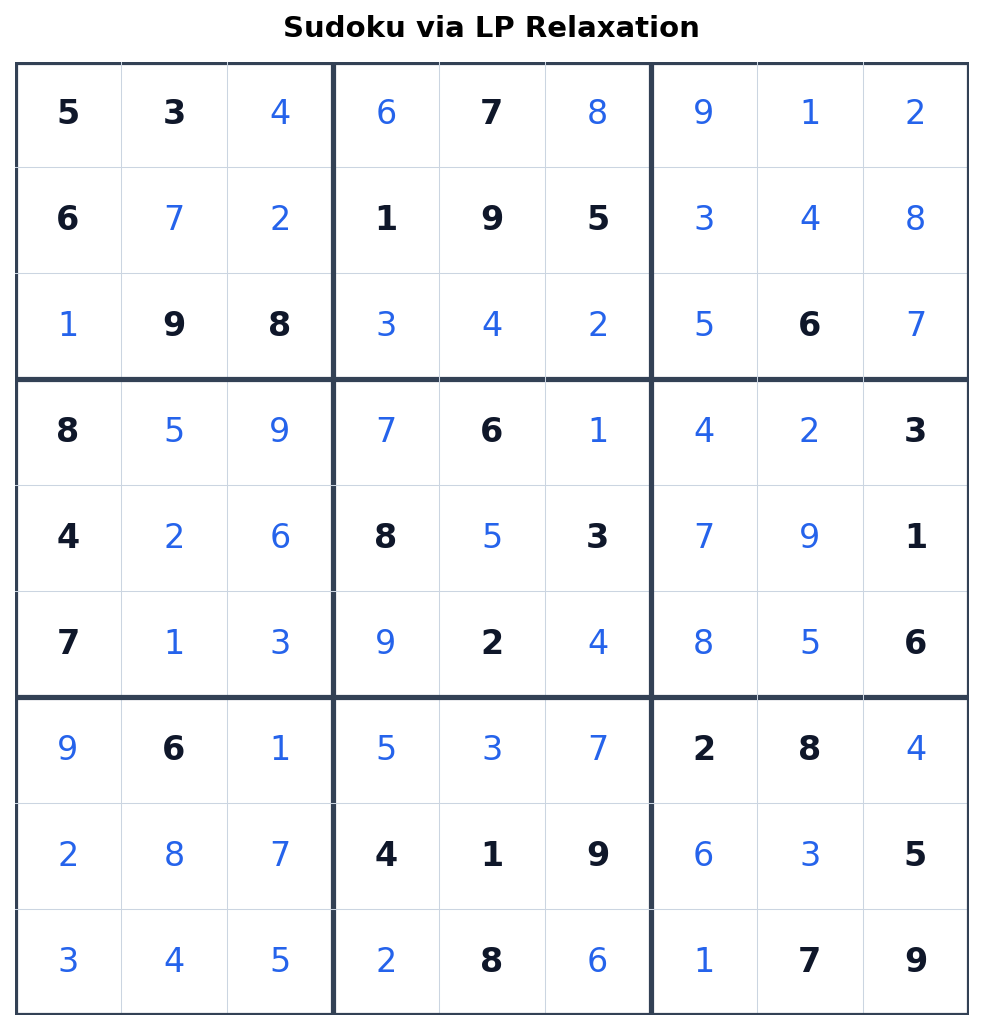

In [6]:
def plot_sudoku_board(board, puzzle, ax=None, title="Sudoku Solution"):
    """Plot a styled 9x9 Sudoku board.

    Parameters
    ----------
    board : ndarray (9, 9) — completed board with digits 1-9
    puzzle : list of list of int — original puzzle (0 = empty)
    ax : matplotlib Axes or None
    title : str
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    else:
        fig = ax.get_figure()

    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=14, pad=12)

    # White background
    ax.set_facecolor('white')

    # Draw grid lines
    for i in range(10):
        lw = 2.5 if i % 3 == 0 else 0.5
        color = '#334155' if i % 3 == 0 else '#CBD5E1'
        ax.axhline(i, color=color, linewidth=lw)
        ax.axvline(i, color=color, linewidth=lw)

    # Fill in digits
    for i in range(9):
        for j in range(9):
            digit = int(board[i, j])
            is_clue = puzzle[i][j] != 0

            if is_clue:
                color = '#0F172A'  # black for clues
                weight = 'bold'
            else:
                color = MOREAU_COLORS['primary']  # blue for solved
                weight = 'normal'

            ax.text(j + 0.5, i + 0.5, str(digit),
                    ha='center', va='center',
                    fontsize=16, fontweight=weight, color=color)

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

    return fig, ax


fig, ax = plt.subplots(figsize=(7, 7))
plot_sudoku_board(board, puzzle, ax=ax, title="Sudoku via LP Relaxation")
plt.tight_layout()
plt.savefig('../assets/sudoku.png', bbox_inches='tight', facecolor='white')
plt.show()

## LP Relaxation: Phase Transition

The LP relaxation doesn't always recover integer solutions. When a puzzle has too few clues it's **under-determined** — multiple valid completions exist, and the LP finds a fractional compromise that satisfies all constraints simultaneously.

We sweep across clue counts (17–40) to map this transition: at what point does the convex relaxation start reliably producing exact integer solutions?

Sweeping clue counts 17–40 (50 trials each)...


Done: 1200 solves
Fractional example: 20 clues, max deviation = 0.4989


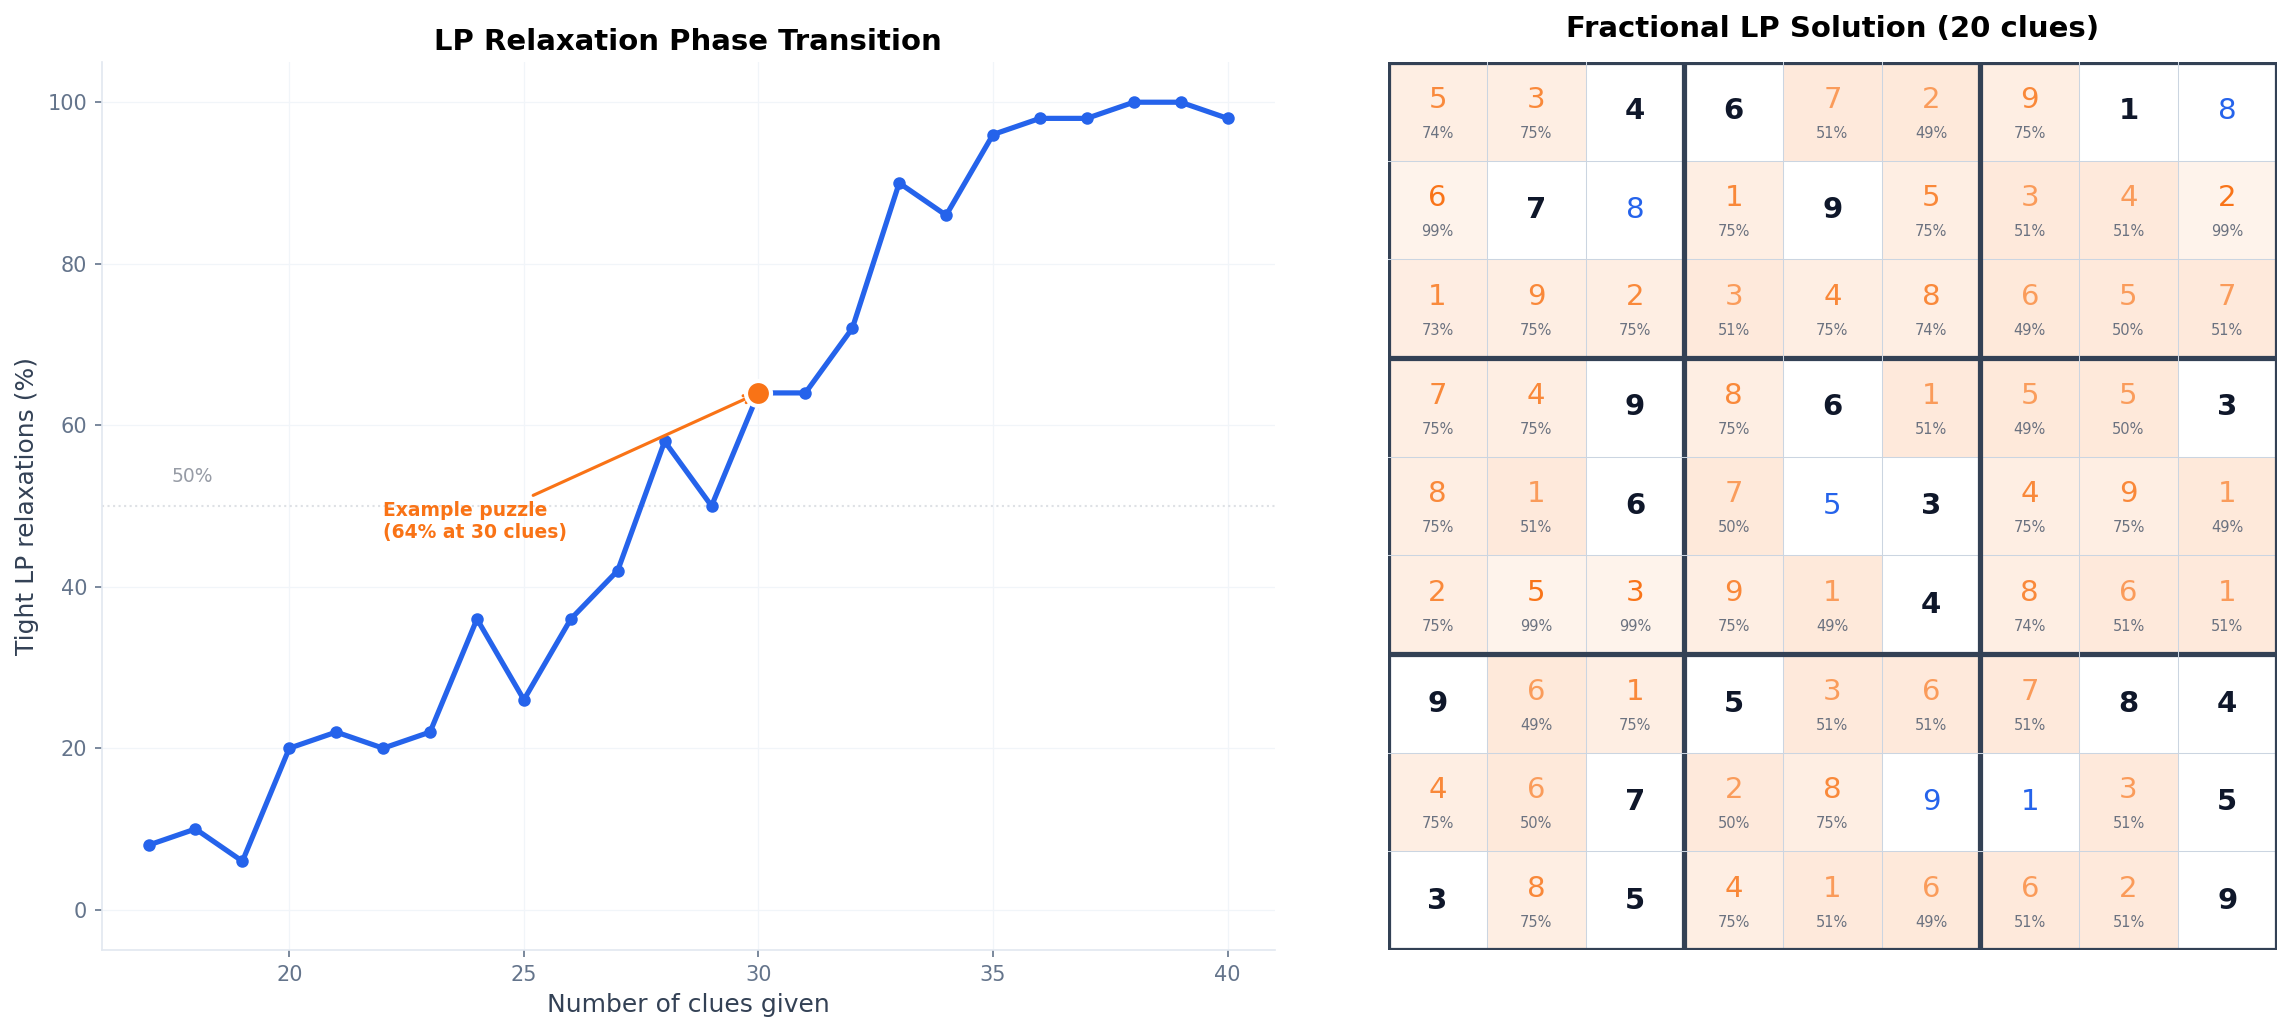

In [7]:
import io
import contextlib

# Known solution (also defined in the batched section below)
solution_board = np.array([
    [5, 3, 4, 6, 7, 8, 9, 1, 2],
    [6, 7, 2, 1, 9, 5, 3, 4, 8],
    [1, 9, 8, 3, 4, 2, 5, 6, 7],
    [8, 5, 9, 7, 6, 1, 4, 2, 3],
    [4, 2, 6, 8, 5, 3, 7, 9, 1],
    [7, 1, 3, 9, 2, 4, 8, 5, 6],
    [9, 6, 1, 5, 3, 7, 2, 8, 4],
    [2, 8, 7, 4, 1, 9, 6, 3, 5],
    [3, 4, 5, 2, 8, 6, 1, 7, 9],
])


def generate_puzzle_from_solution(solution, n_clues, rng):
    """Generate a puzzle by randomly revealing n_clues cells from a known solution."""
    puzzle = [[0] * 9 for _ in range(9)]
    all_cells = [(i, j) for i in range(9) for j in range(9)]
    revealed = rng.choice(len(all_cells), size=n_clues, replace=False)
    for idx in revealed:
        i, j = all_cells[idx]
        puzzle[i][j] = int(solution[i, j])
    return puzzle


# --- Phase transition sweep ---
clue_range = np.arange(17, 41)
n_trials = 50
rng_sweep = np.random.default_rng(42)

pct_valid = np.zeros(len(clue_range))
avg_max_frac = np.zeros(len(clue_range))

print("Sweeping clue counts 17–40 (50 trials each)...")

for ci, nc in enumerate(clue_range):
    n_valid = 0
    frac_devs = []
    for trial in range(n_trials):
        p = generate_puzzle_from_solution(solution_board, nc, rng_sweep)
        with contextlib.redirect_stdout(io.StringIO()):
            P_t, q_t, A_t, b_t, cones_t, _ = build_sudoku_lp(p)
        solver_t = moreau.Solver(P_t, q_t, A_t, b_t, cones=cones_t)
        sol_t = solver_t.solve()
        x_t = sol_t.x.reshape(9, 9, 9)
        max_frac = np.max(np.minimum(x_t, 1 - x_t))
        frac_devs.append(max_frac)
        # Count as valid only if the LP solution is integer AND forms a valid Sudoku
        is_integer = max_frac < 0.01
        board_t = np.argmax(x_t, axis=2) + 1
        if is_integer and verify_sudoku(board_t)[0]:
            n_valid += 1
    pct_valid[ci] = 100.0 * n_valid / n_trials
    avg_max_frac[ci] = np.mean(frac_devs)

print(f"Done: {len(clue_range) * n_trials} solves")

# --- Find a fractional example (~20 clues) ---
frac_rng = np.random.default_rng(7)
for attempt in range(100):
    frac_puzzle = generate_puzzle_from_solution(solution_board, 20, frac_rng)
    with contextlib.redirect_stdout(io.StringIO()):
        P_f, q_f, A_f, b_f, cones_f, _ = build_sudoku_lp(frac_puzzle)
    solver_f = moreau.Solver(P_f, q_f, A_f, b_f, cones=cones_f)
    sol_f = solver_f.solve()
    x_frac = sol_f.x.reshape(9, 9, 9)
    max_frac_val = np.max(np.minimum(x_frac, 1 - x_frac))
    if max_frac_val > 0.1:
        break

n_frac_clues = sum(1 for row in frac_puzzle for v in row if v != 0)
print(f"Fractional example: {n_frac_clues} clues, max deviation = {max_frac_val:.4f}")

# --- Two-panel figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                                gridspec_kw={'width_ratios': [1.1, 1]})

# Left panel: S-curve
ax1.plot(clue_range, pct_valid, 'o-', color=MOREAU_COLORS['primary'],
         linewidth=2.5, markersize=5, zorder=3)

# Mark the 30-clue example puzzle
idx_30 = 30 - 17
ax1.plot(30, pct_valid[idx_30], 'o', color=MOREAU_COLORS['accent'], markersize=12,
         zorder=4, markeredgecolor='white', markeredgewidth=2)
ax1.annotate(f'Example puzzle\n({pct_valid[idx_30]:.0f}% at 30 clues)',
             xy=(30, pct_valid[idx_30]),
             xytext=(22, pct_valid[idx_30] - 18),
             fontsize=9, color=MOREAU_COLORS['accent'], fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=MOREAU_COLORS['accent'], lw=1.5))

# 50% reference line
ax1.axhline(50, color=MOREAU_COLORS['neutral_light'], linestyle=':', linewidth=1, alpha=0.7)
ax1.text(17.5, 53, '50%', fontsize=9, color=MOREAU_COLORS['neutral'], alpha=0.7)

ax1.set_xlabel('Number of clues given')
ax1.set_ylabel('Tight LP relaxations (%)')
ax1.set_title('LP Relaxation Phase Transition')
ax1.set_ylim(-5, 105)
ax1.set_xlim(16, 41)

# Right panel: fractional board
ax2.set_xlim(0, 9)
ax2.set_ylim(0, 9)
ax2.set_aspect('equal')
ax2.invert_yaxis()
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title(f'Fractional LP Solution ({n_frac_clues} clues)', fontsize=14, pad=12)
ax2.set_facecolor('white')

# Grid lines
for li in range(10):
    lw = 2.5 if li % 3 == 0 else 0.5
    color = '#334155' if li % 3 == 0 else '#CBD5E1'
    ax2.axhline(li, color=color, linewidth=lw)
    ax2.axvline(li, color=color, linewidth=lw)

# Fill digits with confidence coloring
probs = np.max(x_frac, axis=2)
best_digits = np.argmax(x_frac, axis=2) + 1

for i in range(9):
    for j in range(9):
        is_clue = frac_puzzle[i][j] != 0
        conf = probs[i, j]
        digit = best_digits[i, j]

        if is_clue:
            ax2.text(j + 0.5, i + 0.5, str(digit), ha='center', va='center',
                     fontsize=14, fontweight='bold', color='#0F172A')
        elif conf > 0.99:
            ax2.text(j + 0.5, i + 0.5, str(digit), ha='center', va='center',
                     fontsize=14, fontweight='normal', color=MOREAU_COLORS['primary'])
        else:
            # Uncertain cell — background tint + digit with confidence
            ax2.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                facecolor=MOREAU_COLORS['accent'],
                alpha=0.08 + 0.15 * (1 - conf),
                edgecolor='none'))
            alpha = 0.3 + 0.7 * conf
            ax2.text(j + 0.5, i + 0.38, str(digit), ha='center', va='center',
                     fontsize=14, fontweight='normal',
                     color=MOREAU_COLORS['accent'], alpha=alpha)
            ax2.text(j + 0.5, i + 0.72, f'{conf:.0%}', ha='center', va='center',
                     fontsize=7, color=MOREAU_COLORS['neutral'])

for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.grid(False)

plt.tight_layout()
plt.savefig('../assets/sudoku_phase.png', bbox_inches='tight', facecolor='white')
plt.show()

## Batched: 256 Puzzles Simultaneously

Using `CompiledSolver` with `batch_size=256`, we solve 256 different Sudoku puzzles in a single batched call on GPU. All puzzles share the same structural constraints (324 equalities + box bounds) but differ in their clue constraints.

In [8]:
# The known solution for our base puzzle (used to generate variants)
solution_board = np.array([
    [5, 3, 4, 6, 7, 8, 9, 1, 2],
    [6, 7, 2, 1, 9, 5, 3, 4, 8],
    [1, 9, 8, 3, 4, 2, 5, 6, 7],
    [8, 5, 9, 7, 6, 1, 4, 2, 3],
    [4, 2, 6, 8, 5, 3, 7, 9, 1],
    [7, 1, 3, 9, 2, 4, 8, 5, 6],
    [9, 6, 1, 5, 3, 7, 2, 8, 4],
    [2, 8, 7, 4, 1, 9, 6, 3, 5],
    [3, 4, 5, 2, 8, 6, 1, 7, 9],
])


def generate_puzzle_from_solution(solution, n_clues=30, rng=None):
    """Generate a puzzle by randomly revealing n_clues cells from a known solution."""
    if rng is None:
        rng = np.random.default_rng()
    puzzle = [[0] * 9 for _ in range(9)]
    # Choose which cells to reveal
    all_cells = [(i, j) for i in range(9) for j in range(9)]
    revealed = rng.choice(len(all_cells), size=n_clues, replace=False)
    for idx in revealed:
        i, j = all_cells[idx]
        puzzle[i][j] = int(solution[i, j])
    return puzzle


# Generate 256 different puzzles by varying which clues are revealed
n_batch = 256
batch_rng = np.random.default_rng(123)
batch_puzzles = []
for b in range(n_batch):
    n_clues = batch_rng.integers(25, 36)  # vary difficulty
    p = generate_puzzle_from_solution(solution_board, n_clues=n_clues, rng=batch_rng)
    batch_puzzles.append(p)

clue_counts = [sum(1 for row in p for v in row if v != 0) for p in batch_puzzles]
print(f"Generated {n_batch} puzzles with clue count range: [{min(clue_counts)}, {max(clue_counts)}]")

Generated 256 puzzles with clue count range: [25, 35]


In [9]:
# For batched solving, we need all puzzles to have the same constraint structure.
# Strategy: use the maximum number of clues across all puzzles, padding shorter
# ones with redundant clue constraints (re-asserting an existing structural constraint).
#
# Alternatively, we build a common structure with a fixed number of clue slots.
# Here we use a simpler approach: encode clues via q and b manipulation.
#
# The structural constraints (324 eq + 1458 nonneg) are shared. For clues, we
# fix variables by tightening both bounds: x[i,j,k] >= 1 and x[i,j,k] <= 1
# for clue digits, and x[i,j,k] <= 0 for non-clue digits in clue cells.
# This way the A matrix structure is identical across all problems — only b differs.

n_vars = 729
n_structural_eq = 324

# Build the shared structural constraint matrix (no clue equalities)
eq_rows_data = []  # (row, col, val)
row_counter = 0

# Cell constraints
for i in range(9):
    for j in range(9):
        for k in range(9):
            eq_rows_data.append((row_counter, var_index(i, j, k), 1.0))
        row_counter += 1

# Row constraints
for i in range(9):
    for k in range(9):
        for j in range(9):
            eq_rows_data.append((row_counter, var_index(i, j, k), 1.0))
        row_counter += 1

# Column constraints
for j in range(9):
    for k in range(9):
        for i in range(9):
            eq_rows_data.append((row_counter, var_index(i, j, k), 1.0))
        row_counter += 1

# Box constraints
for box_r in range(3):
    for box_c in range(3):
        for k in range(9):
            for di in range(3):
                for dj in range(3):
                    ii = box_r * 3 + di
                    jj = box_c * 3 + dj
                    eq_rows_data.append((row_counter, var_index(ii, jj, k), 1.0))
            row_counter += 1

assert row_counter == n_structural_eq

eq_r = np.array([r for (r, c, v) in eq_rows_data])
eq_c = np.array([c for (r, c, v) in eq_rows_data])
eq_v = np.array([v for (r, c, v) in eq_rows_data], dtype=np.float64)

A_eq_shared = sparse.csr_array(
    (eq_v, (eq_r, eq_c)), shape=(n_structural_eq, n_vars)
)
b_eq_shared = np.ones(n_structural_eq, dtype=np.float64)

# Bounds: -I (lower) and I (upper)
A_lower = -sparse.eye(n_vars, dtype=np.float64, format='csr')
A_upper = sparse.eye(n_vars, dtype=np.float64, format='csr')

# Full A matrix (shared structure): [equalities; lower bounds; upper bounds]
A_batch_full = sparse.vstack([A_eq_shared, A_lower, A_upper], format='csr')
A_batch_full.sort_indices()

n_eq_batch = n_structural_eq
n_nonneg_batch = 2 * n_vars
m_total = n_eq_batch + n_nonneg_batch

cones_batch = moreau.Cones(num_zero_cones=n_eq_batch, num_nonneg_cones=n_nonneg_batch)

print(f"Shared A shape: {A_batch_full.shape}, nnz = {A_batch_full.nnz}")
print(f"Equalities: {n_eq_batch}, Nonneg: {n_nonneg_batch}, Total: {m_total}")


def build_batch_b(puzzle):
    """Build the b vector for a puzzle using bound tightening for clues.

    Clue encoding via bounds:
    - For clue cell (i,j) with digit d:
      - x[i,j,d-1] >= 1 (tighten lower bound from 0 to 1)
      - For k != d-1: x[i,j,k] <= 0 (tighten upper bound from 1 to 0)
    """
    b_lower = np.zeros(n_vars, dtype=np.float64)  # default: x >= 0
    b_upper = np.ones(n_vars, dtype=np.float64)   # default: x <= 1

    for i in range(9):
        for j in range(9):
            if puzzle[i][j] != 0:
                d = puzzle[i][j]
                # Fix x[i,j,d-1] = 1 via bounds
                idx_correct = var_index(i, j, d - 1)
                b_lower[idx_correct] = 1.0   # -x <= -1  =>  x >= 1
                # Fix x[i,j,k] = 0 for k != d-1
                for k in range(9):
                    if k != d - 1:
                        idx_other = var_index(i, j, k)
                        b_upper[idx_other] = 0.0  # x <= 0

    # b = [b_eq; -b_lower; b_upper]
    # lower: -x + s = -lower_bound  =>  s = x - lower_bound >= 0
    # Wait — we have A_lower = -I, so -x + s = b_lower_rhs
    # For x >= L: -x + s = -L  =>  s = x - L >= 0
    b_lower_rhs = -b_lower  # negate because A_lower = -I

    return np.concatenate([b_eq_shared, b_lower_rhs, b_upper])


# Build q and b for all 256 puzzles
rng_q = np.random.default_rng(0)
q_shared = rng_q.uniform(1e-6, 1e-5, size=n_vars).astype(np.float64)

qs_all = np.tile(q_shared, (n_batch, 1))  # same q for all
bs_all = np.zeros((n_batch, m_total), dtype=np.float64)
for idx in range(n_batch):
    bs_all[idx] = build_batch_b(batch_puzzles[idx])

# Build CompiledSolver
P_batch = sparse.csr_array((n_vars, n_vars), dtype=np.float64)
P_ro, P_ci, P_vals = sparse_to_csr(P_batch)
A_ro, A_ci, A_vals = sparse_to_csr(A_batch_full)

settings = moreau.Settings(batch_size=n_batch)
compiled = moreau.CompiledSolver(
    n=n_vars, m=m_total,
    P_row_offsets=P_ro, P_col_indices=P_ci,
    A_row_offsets=A_ro, A_col_indices=A_ci,
    cones=cones_batch, settings=settings,
)
compiled.setup(P_vals, A_vals)

batch_sol = compiled.solve(qs=qs_all, bs=bs_all)

# Solved and AlmostSolved both produce LP solutions whose argmax rounds to a
# valid sudoku grid; the distinction is only in the IPM's convergence tolerance.
SUCCESS = {moreau.SolverStatus.Solved, moreau.SolverStatus.AlmostSolved}
n_solved = sum(1 for s in compiled.info.status if s in SUCCESS)
print(f"\nSolved {n_solved}/{n_batch} Sudoku puzzles in a single batched call")

# Extract and verify all solutions
batch_boards = []
for idx in range(n_batch):
    x_b = batch_sol.x[idx].reshape(9, 9, 9)
    board_b = np.argmax(x_b, axis=2) + 1
    batch_boards.append(board_b)

n_valid = sum(1 for b in batch_boards if verify_sudoku(b)[0])
print(f"Valid solutions: {n_valid}/{n_batch}")

Shared A shape: (1782, 729), nnz = 4374
Equalities: 324, Nonneg: 1458, Total: 1782



Solved 256/256 Sudoku puzzles in a single batched call
Valid solutions: 189/256


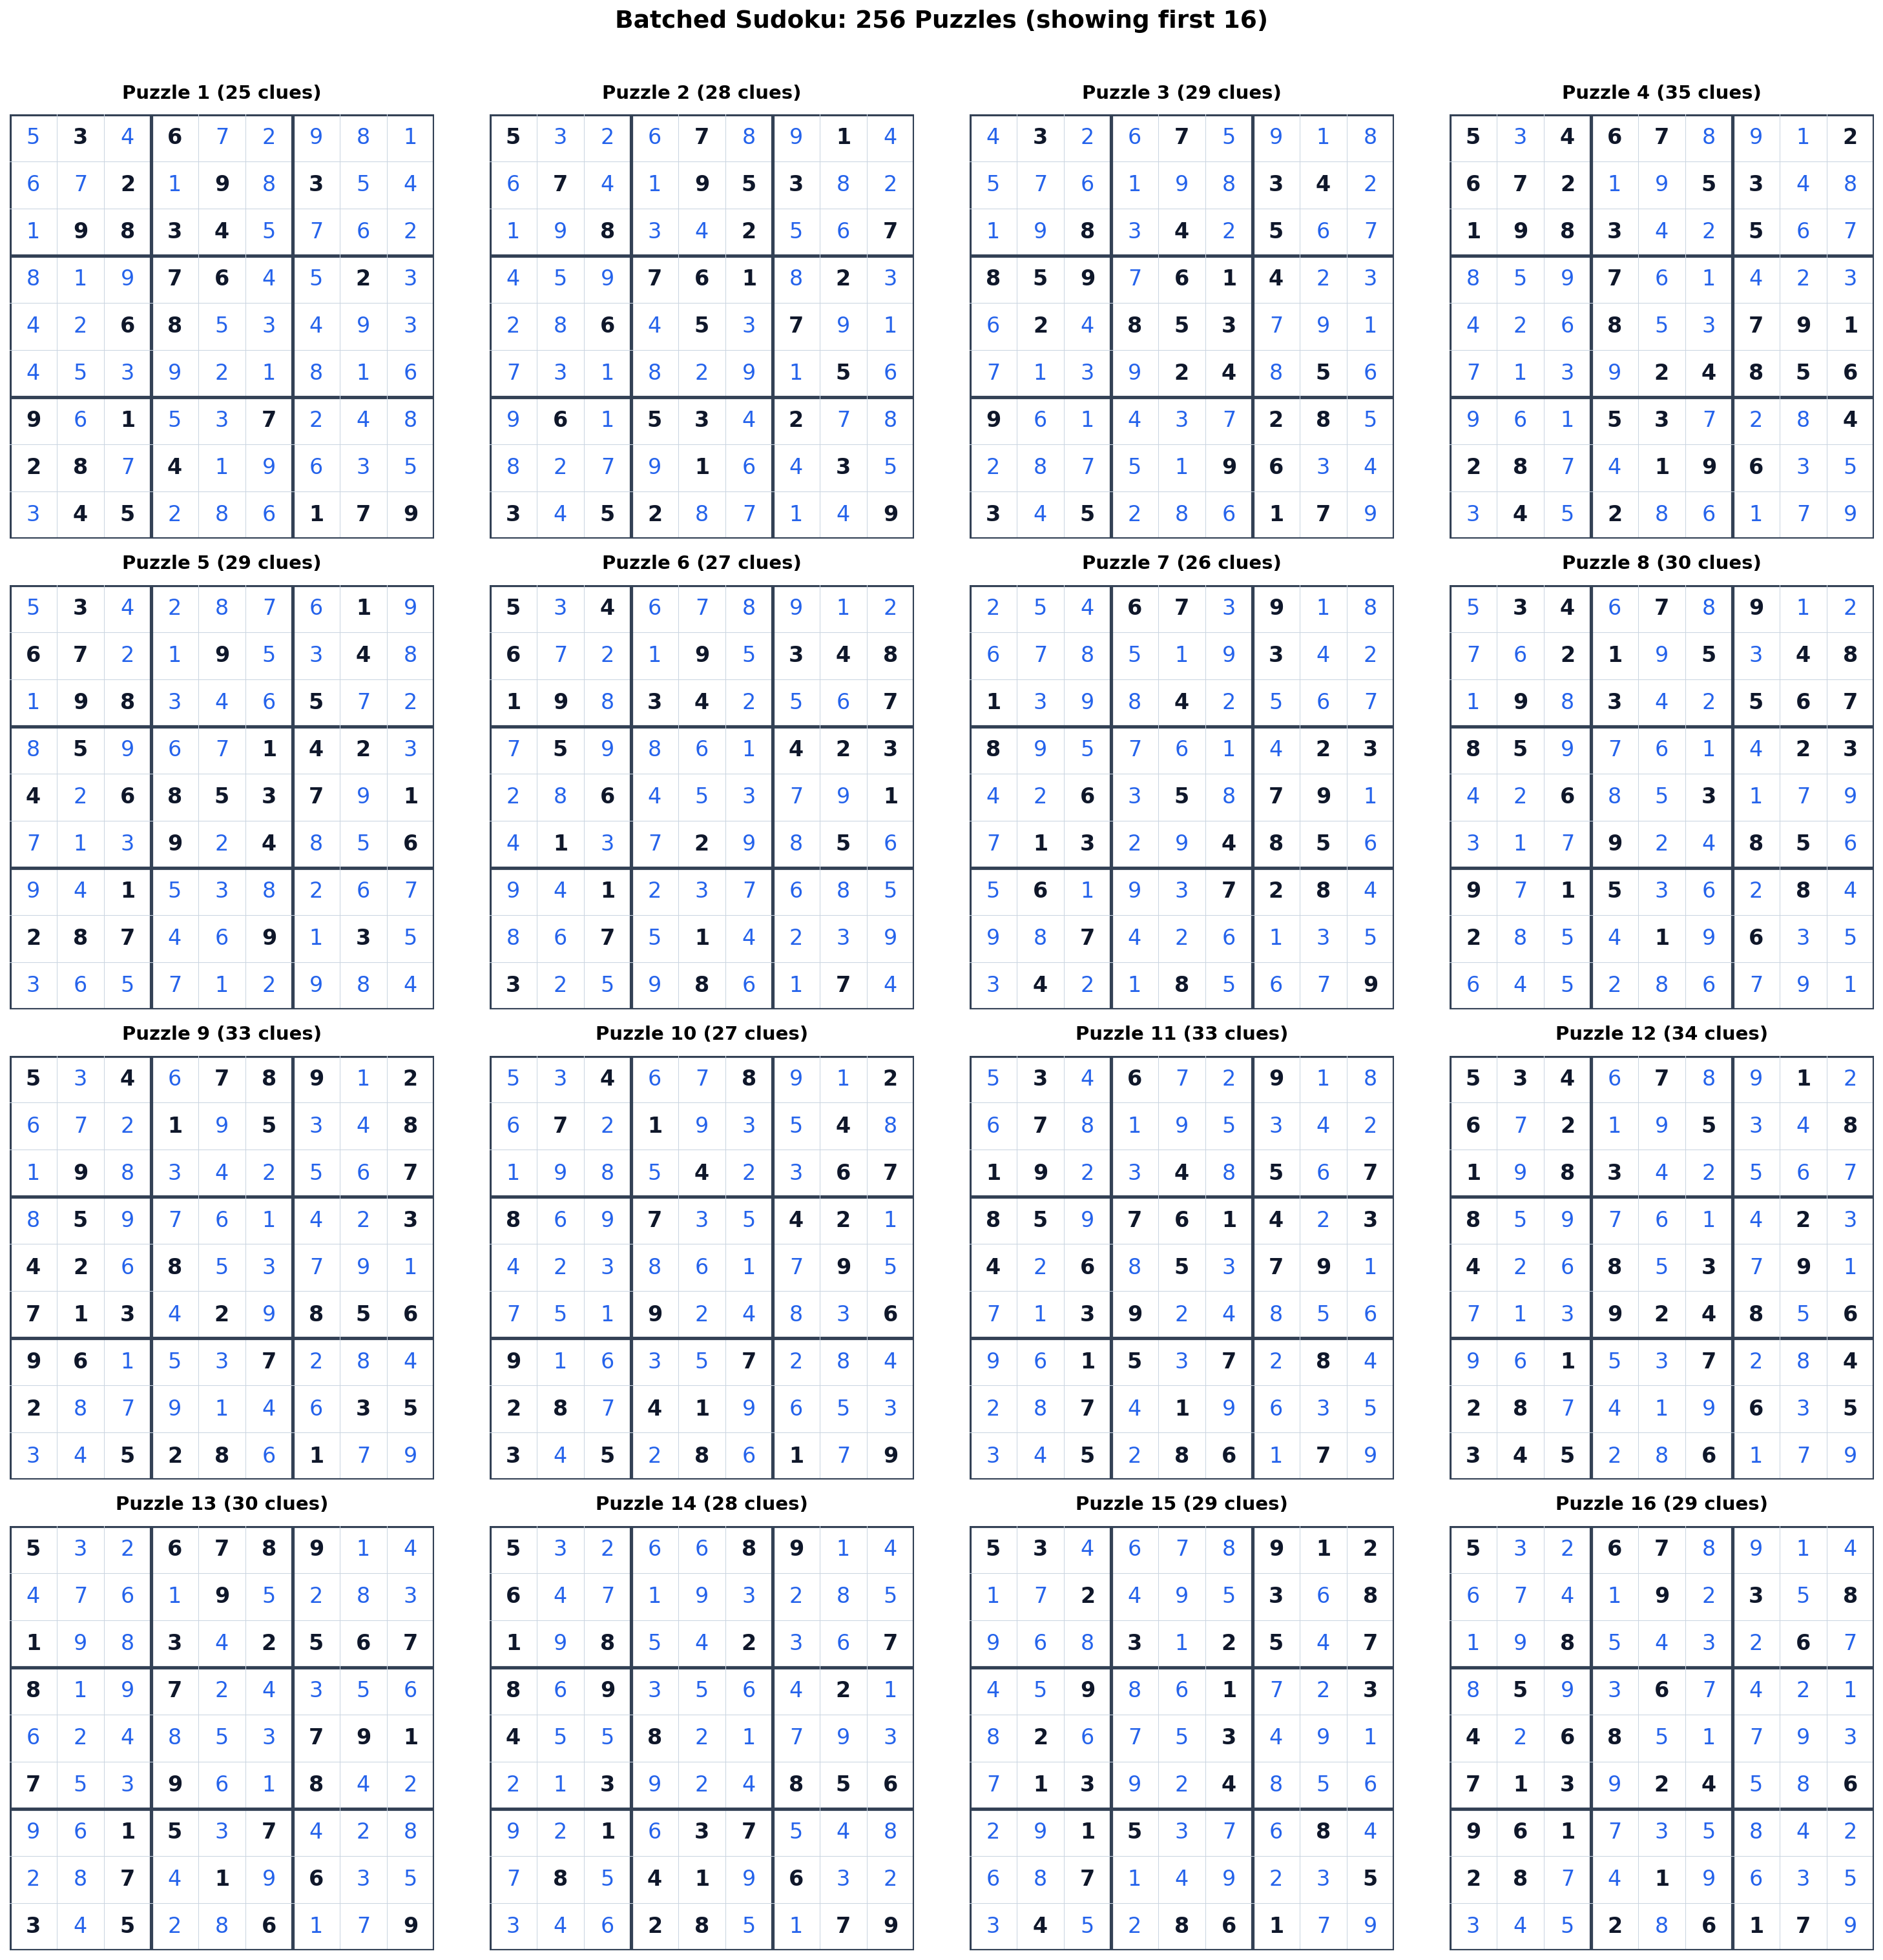

In [10]:
# Display 4x4 grid of selected solved boards (first 16 of 256)
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

for idx in range(16):
    ax = axes[idx // 4][idx % 4]
    n_clues_i = sum(1 for row in batch_puzzles[idx] for v in row if v != 0)
    plot_sudoku_board(
        batch_boards[idx], batch_puzzles[idx], ax=ax,
        title=f"Puzzle {idx + 1} ({n_clues_i} clues)"
    )

fig.suptitle(f'Batched Sudoku: {n_batch} Puzzles (showing first 16)',
             fontsize=18, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/sudoku_batch.png', bbox_inches='tight', facecolor='white')
plt.show()

---

**Key takeaways:**
- Sudoku can be formulated as a linear program with 729 variables and 324 structural equality constraints
- The LP relaxation ($0 \le x \le 1$ instead of $x \in \{0,1\}$) recovers the exact integer solution for well-posed puzzles
- There's a phase transition around 28–30 clues — below this threshold the LP produces genuinely fractional solutions reflecting combinatorial ambiguity
- Clues are enforced by tightening variable bounds, keeping the constraint structure identical across puzzles
- `CompiledSolver` solves 256 puzzles in a single batched GPU call, with clue differences encoded entirely in the $b$ vector